# Unified Binary Classification Pipeline

This notebook consolidates the different approaches (standard ML models (`sklearn`), interpretable models (`imodels`), and competitive approaches from literature) into a single pipeline with:
- 90/10 stratified train/test split
- GridSearchCV scoring various metrics
- Confusion matrices and results
- Threshold tuning (PR-optimal and Youden's J)
- Best model & config summary per approach and per model category
- Feature importance of the best model per approach and model category

## 1. Setup & Imports

In [1]:
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Suppress noisy sklearn convergence warnings during grid search
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from collections import defaultdict
from math import ceil



# Project imports
from src.models import (
    SKLEARN_MODELS_SEARCH_SPACE,
    INTERPRETABLE_MODELS_SEARCH_SPACE,
    RANDOM_STATE,
)
from src.utils import (
    load_metabric_data,
    prepare_data_splits_per_model,
)

from src.competitors import export_results

## 2. Load & Preprocess Data

In [3]:
_, df = load_metabric_data()
df.shape

Fetching METABRIC dataset from Kaggle...

Original dataset was loaded, shape: (1904, 693)
Original dataset was preprocessed, given a new shape: (679, 684)


(679, 684)

## 3. Define Feature-Space Experiments (Approaches)

Each approach defines a different feature space. The 90/10 stratified train/test split and the preprocessor are built per approach via `prepare_data_splits_per_model`.

In [4]:
# Each experiment = (feature-space approach, dict of models to try)
EXPERIMENTS = [
    ("with_augmentation",  SKLEARN_MODELS_SEARCH_SPACE),
    ("with_augmentation",  INTERPRETABLE_MODELS_SEARCH_SPACE),
    ("pure_numerical",     SKLEARN_MODELS_SEARCH_SPACE),
    ("pure_numerical",     INTERPRETABLE_MODELS_SEARCH_SPACE),
    ("rezaeian",           SKLEARN_MODELS_SEARCH_SPACE),
    ("rezaeian",     INTERPRETABLE_MODELS_SEARCH_SPACE),
    ("kurniadi",           SKLEARN_MODELS_SEARCH_SPACE),
    ("kurniadi",     INTERPRETABLE_MODELS_SEARCH_SPACE),
]

## 4. Define Scoring & Helper Functions

In [5]:
SCORING = {
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy',
    'average_precision': 'average_precision',
    'f1': 'f1',
}

REFIT_METRIC = 'roc_auc' 

In [6]:
def make_full_pipeline(preprocessor, classifier):
    """Combine the preprocessing pipeline with a classifier step."""
    return Pipeline([
        *preprocessor.steps,
        ('classifier', classifier),
    ])


def evaluate_at_threshold(y_true, proba, threshold):
    """Return predictions and key metrics at a given threshold."""
    preds = (proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'f1': f1_score(y_true, preds),
        'balanced_acc': balanced_accuracy_score(y_true, preds),
        'roc_auc': roc_auc_score(y_true, preds),
        'predictions': preds,
    }


def find_best_threshold_pr(y_true, proba):
    """Find threshold maximizing F1 on the precision-recall curve."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, proba)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = int(np.argmax(f1_scores))
    return thresholds[min(best_idx, len(thresholds) - 1)]


def find_best_threshold_youden(y_true, proba):
    """Find threshold maximizing Youden's J statistic on the ROC curve."""
    fpr, tpr, thresholds = roc_curve(y_true, proba)
    j_scores = tpr - fpr
    return thresholds[int(np.argmax(j_scores))]


def plot_confusion_matrix(y_true, preds, title=''):
    """Display confusion matrix."""
    ConfusionMatrixDisplay.from_predictions(y_true, preds, cmap='Blues')
    plt.title(title)
    plt.show()

## 5. Run All Experiments

Outer loop: **feature-space approach** (e.g. `with_augmentation`, `pure_numerical`, `rezaeian`, `kurniadi`).  
Inner loop: **models** from the corresponding model registry.

In [7]:
from copy import deepcopy

CV_FOLDS = 3

results = []  # one dict per (approach, model_family, model)

for approach, model_registry in EXPERIMENTS:
    # Determine a readable model-family label
    if model_registry is SKLEARN_MODELS_SEARCH_SPACE:
        model_family = "Standard ML"
    elif model_registry is INTERPRETABLE_MODELS_SEARCH_SPACE:
        model_family = "Interpretable"
    else:
        model_family = "Custom"

    print(f"\n{'='*70}")
    print(f"  Approach: {approach}  |  Models: {model_family}")
    print(f"{'='*70}")

    # Build data split + preprocessor for this feature space
    X_train, X_test, y_train, y_test, preprocessor_builder = \
        prepare_data_splits_per_model(approach=approach, df=df)

    preprocess_pipeline = preprocessor_builder(X_train)

    for model_name, (estimator, param_grid) in model_registry.items():
        print(f"\n--- {model_name} ---")

        # Build full pipeline: preprocessor steps + classifier
        pipe = Pipeline([
            *preprocess_pipeline.steps,
            ('classifier', deepcopy(estimator)),
        ])

        grid = GridSearchCV(
            pipe,
            param_grid,
            cv=CV_FOLDS,
            scoring=SCORING,
            refit=REFIT_METRIC,
            n_jobs=-1,
            error_score=np.nan,
        )

        try:
            grid.fit(X_train, y_train)
        except Exception as e:
            print(f"  [SKIP] {model_name} failed: {e}")
            continue

        proba = grid.predict_proba(X_test)[:, 1]

        # CV scores (from the best index chosen by REFIT_METRIC)
        best_idx = grid.best_index_
        cv_auc = grid.best_score_
        cv_bal_acc = grid.cv_results_['mean_test_balanced_accuracy'][best_idx]
        cv_ap = grid.cv_results_['mean_test_average_precision'][best_idx]
        cv_f1 = grid.cv_results_['mean_test_f1'][best_idx]

        # Test scores at default threshold
        y_pred_default = grid.predict(X_test)
        test_auc = roc_auc_score(y_test, proba)
        test_ap = average_precision_score(y_test, proba)
        test_bal_acc = balanced_accuracy_score(y_test, y_pred_default)
        test_f1 = f1_score(y_test, y_pred_default)

        print(
            f"  CV AUC={cv_auc:.3f}  CV AP={cv_ap:.3f}  CV F1={cv_f1:.3f}  CV BalAcc={cv_bal_acc:.3f} | "
            f"Test AUC={test_auc:.3f}  Test AP={test_ap:.3f}  Test F1={test_f1:.3f}  Test BalAcc={test_bal_acc:.3f}"
        )

        results.append({
            'feature_space': approach,
            'model_family': model_family,
            'model': model_name,
            'best_params': grid.best_params_,
            'cv_auc': cv_auc,
            'cv_ap': cv_ap,
            'cv_f1': cv_f1,
            'cv_bal_acc': cv_bal_acc,
            'test_auc': test_auc,
            'test_ap': test_ap,
            'test_f1': test_f1,
            'test_bal_acc': test_bal_acc,
            'proba': proba,
            'y_test': y_test,
            'X_test': X_test,        
            'grid': grid,
        })

print(f"\n\nFinished: {len(results)} model runs collected.")


  Approach: with_augmentation  |  Models: Standard ML

Applying one-hot encoding to categorical columns: 
cancer_type_detailed               5 levels
er_status_measured_by_ihc          2 levels
her2_status_measured_by_snp6       4 levels
tumor_other_histologic_subtype     6 levels
inferred_menopausal_state          2 levels
integrative_cluster               11 levels
primary_tumor_laterality           2 levels
oncotree_code                      5 levels
3-gene_classifier_subtype          3 levels
dtype: str

---------


New columns after one-hot encoding:
3-gene_classifier_subtype_ER+/HER2- Low Prolif
3-gene_classifier_subtype_HER2+
cancer_type_detailed_Breast Invasive Ductal Carcinoma
cancer_type_detailed_Breast Invasive Lobular Carcinoma
cancer_type_detailed_Breast Invasive Mixed Mucinous Carcinoma
cancer_type_detailed_Breast Mixed Ductal and Lobular Carcinoma
er_status_measured_by_ihc_Positve
her2_status_measured_by_snp6_LOSS
her2_status_measured_by_snp6_NEUTRAL
her2_status_measure

/Users/lemnos/Documents/gits/DAMA_Hackathon/src/utils.py:169: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


  CV AUC=0.667  CV AP=0.364  CV F1=0.161  CV BalAcc=0.536 | Test AUC=0.658  Test AP=0.426  Test F1=0.125  Test BalAcc=0.533

--- Random Forest ---
  CV AUC=0.661  CV AP=0.344  CV F1=0.000  CV BalAcc=0.500 | Test AUC=0.731  Test AP=0.435  Test F1=0.000  Test BalAcc=0.500

--- SVM ---
  CV AUC=0.677  CV AP=0.376  CV F1=0.000  CV BalAcc=0.500 | Test AUC=0.623  Test AP=0.415  Test F1=0.000  Test BalAcc=0.500

  Approach: with_augmentation  |  Models: Interpretable

Applying one-hot encoding to categorical columns: 
cancer_type_detailed               5 levels
er_status_measured_by_ihc          2 levels
her2_status_measured_by_snp6       4 levels
tumor_other_histologic_subtype     6 levels
inferred_menopausal_state          2 levels
integrative_cluster               11 levels
primary_tumor_laterality           2 levels
oncotree_code                      5 levels
3-gene_classifier_subtype          3 levels
dtype: str

---------


New columns after one-hot encoding:
3-gene_classifier_subtype_E

/Users/lemnos/Documents/gits/DAMA_Hackathon/src/utils.py:169: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns


  CV AUC=0.646  CV AP=0.338  CV F1=0.265  CV BalAcc=0.559 | Test AUC=0.482  Test AP=0.234  Test F1=0.087  Test BalAcc=0.467

--- RuleFit ---
  CV AUC=0.724  CV AP=0.446  CV F1=0.000  CV BalAcc=0.500 | Test AUC=0.724  Test AP=0.464  Test F1=0.000  Test BalAcc=0.500

--- BoostedRules ---
  CV AUC=0.663  CV AP=0.363  CV F1=0.133  CV BalAcc=0.527 | Test AUC=0.752  Test AP=0.538  Test F1=0.125  Test BalAcc=0.533

--- GreedyTree ---
  CV AUC=0.622  CV AP=0.282  CV F1=0.127  CV BalAcc=0.512 | Test AUC=0.640  Test AP=0.333  Test F1=0.095  Test BalAcc=0.486

  Approach: pure_numerical  |  Models: Standard ML
Train: (611, 498), Test: (68, 498)
Train target distribution:
target_mortality
0    480
1    131
Name: count, dtype: int64
Test  target distribution:
target_mortality
0    53
1    15
Name: count, dtype: int64
Missing columns report: 
 cellularity                    7
neoplasm_histologic_grade     28
mutation_count                 7
tumor_size                     1
tumor_stage               

## 6. Confusion Matrices (Default Threshold = 0.5)

In [8]:
# for r in results:
#     preds = r['grid'].predict(r['X_test'])
#     title = f"{r['feature_space']} / {r['model_family']} / {r['model']}  (AUC={r['test_auc']:.3f} F1={r['test_f1']:.3f})"
#     plot_confusion_matrix(r['y_test'], preds, title=title)


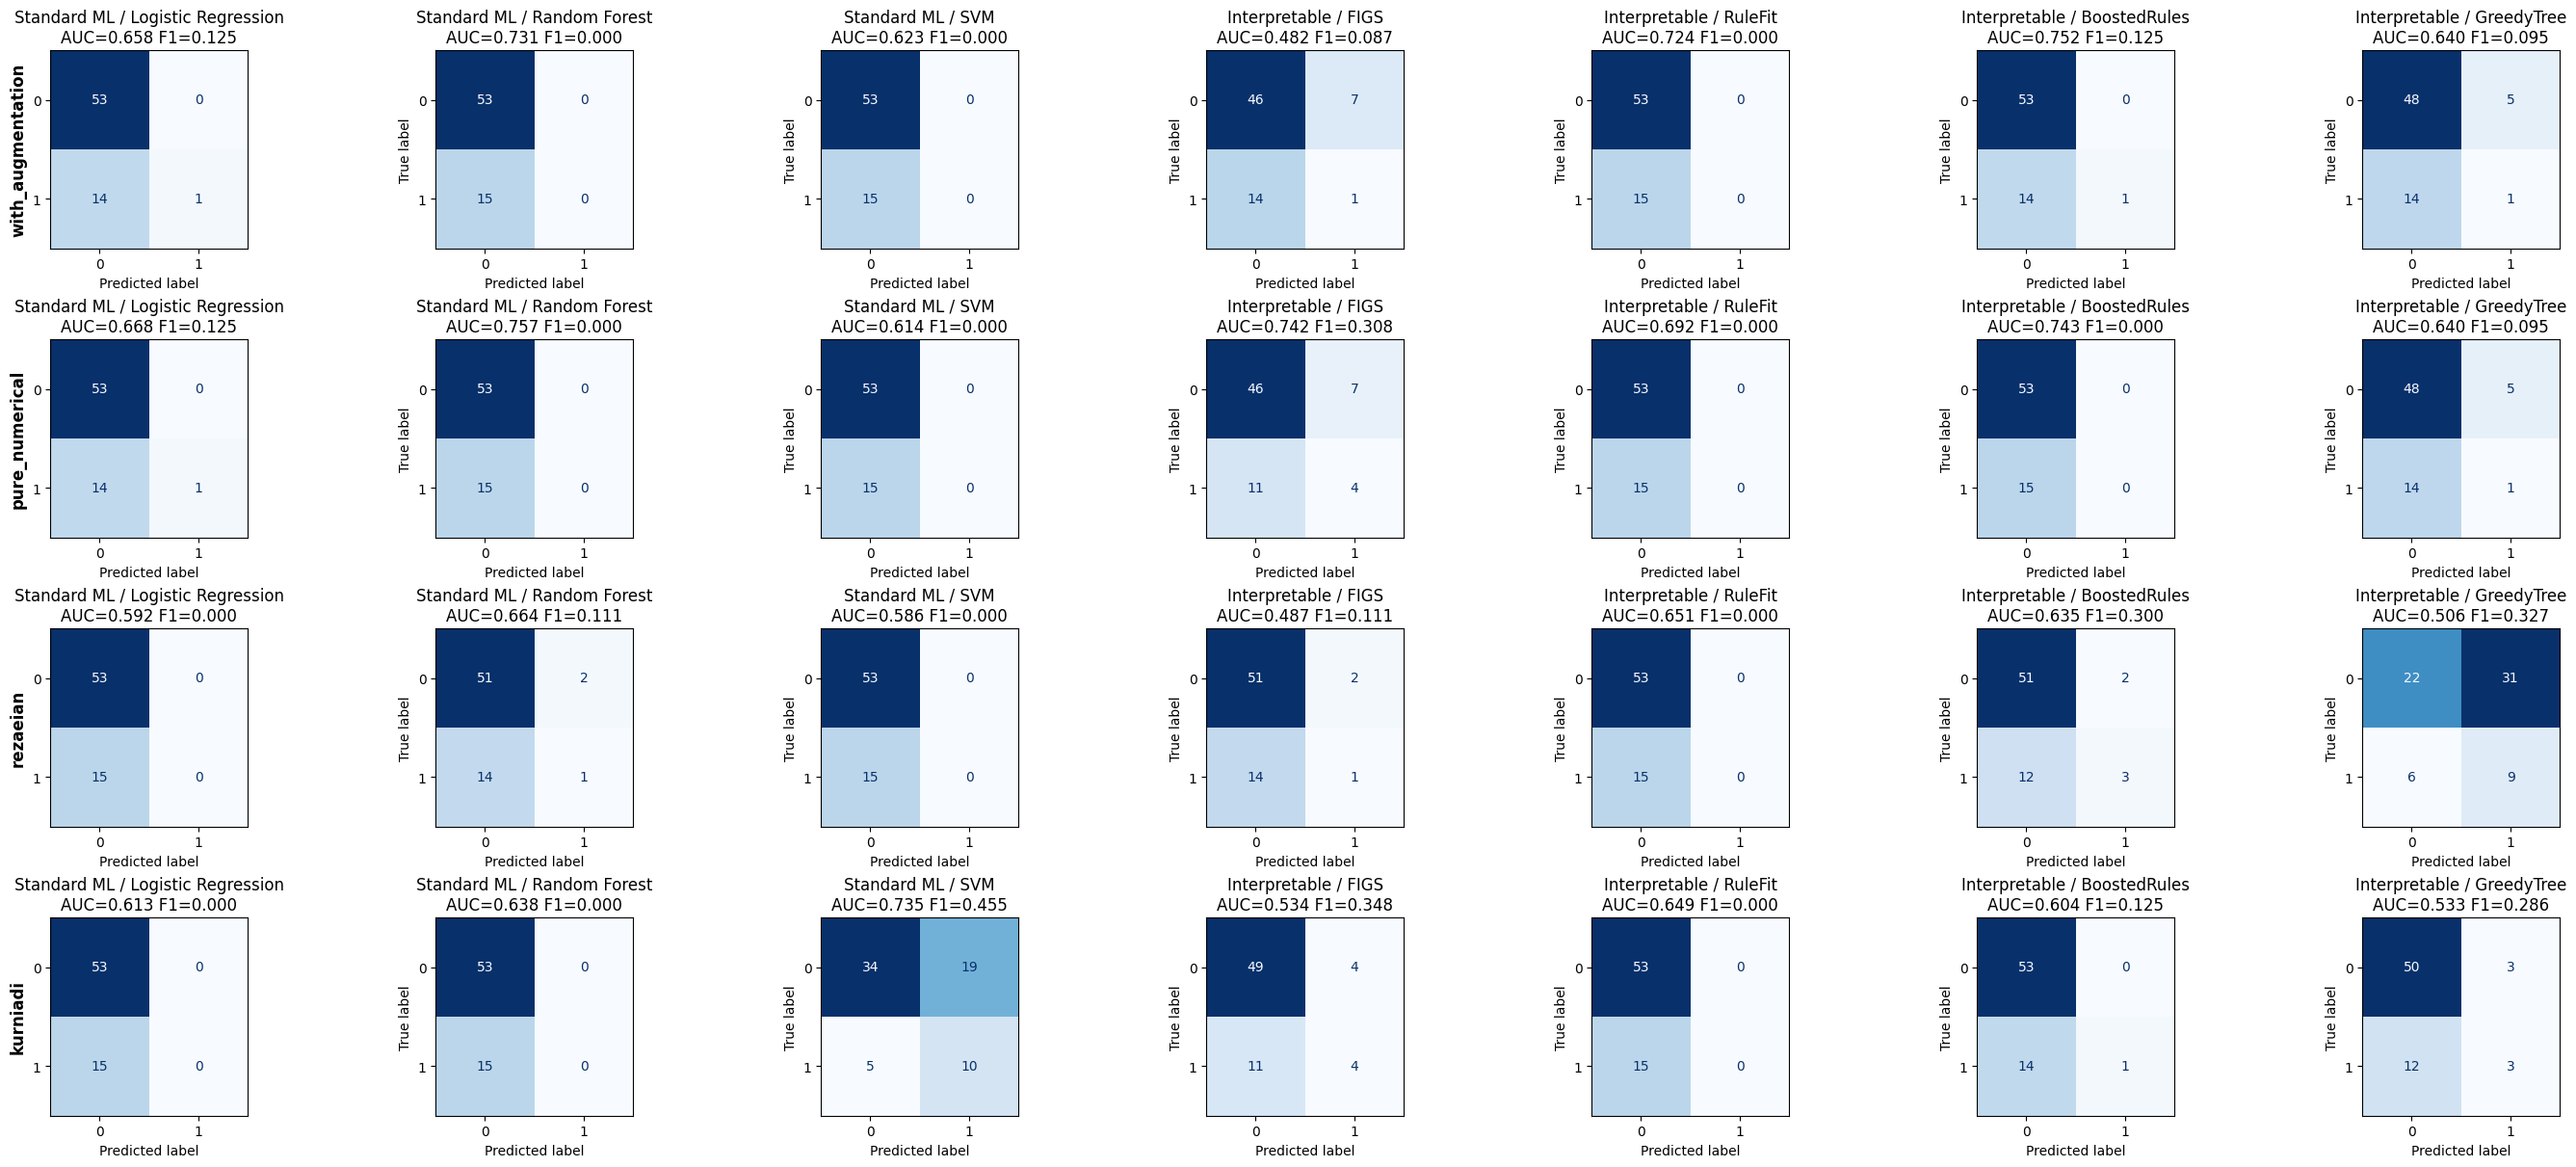

In [9]:
def plot_confusion_matrix(y_true, y_pred, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(title)


# --- Group results by feature_space ---
grouped = defaultdict(list)
for r in results:
    grouped[r["feature_space"]].append(r)

# --- Grid size ---
n_rows = len(grouped)
n_cols = max(len(models) for models in grouped.values())

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4 * n_cols, 3 * n_rows)
)

# Ensure axes is always 2D
axes = np.atleast_2d(axes)

# --- Plot everything inside the grid ---
for row_idx, (fs, row_results) in enumerate(grouped.items()):
    for col_idx, r in enumerate(row_results):
        ax = axes[row_idx, col_idx]

        preds = r["grid"].predict(r["X_test"])
        title = (
            f"{r['model_family']} / {r['model']}\n"
            f"AUC={r['test_auc']:.3f} F1={r['test_f1']:.3f}"
        )

        plot_confusion_matrix(
            r["y_test"],
            preds,
            title=title,
            ax=ax
        )

        # Y label only on first column
        if col_idx == 0:
            ax.set_ylabel(fs, fontsize=12, fontweight="bold")

    # Hide unused columns in this row
    for col_idx in range(len(row_results), n_cols):
        axes[row_idx, col_idx].axis("off")

# --- Layout & display ---
fig.set_constrained_layout(True)
plt.show()

## 7. Threshold Tuning

For each trained model we compute:
- **PR-optimal** threshold (maximizes F1)
- **Youden's J** threshold (maximizes TPR − FPR)

In [10]:
tuned_rows = []

for r in results:
    proba = r['proba']
    y_t = r['y_test']

    # PR-optimal threshold
    thr_pr = find_best_threshold_pr(y_t, proba)
    eval_pr = evaluate_at_threshold(y_t, proba, thr_pr)

    # Youden's J threshold
    thr_j = find_best_threshold_youden(y_t, proba)
    eval_j = evaluate_at_threshold(y_t, proba, thr_j)

    tuned_rows.append({
        'feature_space': r['feature_space'],
        'model_family': r['model_family'],
        'model': r['model'],
        'default_f1': r['test_f1'],
        'pr_threshold': thr_pr,
        'pr_f1': eval_pr['f1'],
        'pr_bal_acc': eval_pr['balanced_acc'],
        'youden_threshold': thr_j,
        'youden_f1': eval_j['f1'],
        'youden_bal_acc': eval_j['balanced_acc'],
    })

df_tuned = pd.DataFrame(tuned_rows)
df_tuned = df_tuned.round(3)
df_tuned

,feature_space,model_family,model,default_f1,pr_threshold,pr_f1,pr_bal_acc,youden_threshold,youden_f1,youden_bal_acc
0,with_augmentation,Standard ML,Logistic Regression,0.125,0.142,0.475,0.684,0.142,0.475,0.684
1,with_augmentation,Standard ML,Random Forest,0.000,0.209,0.545,0.740,0.209,0.545,0.740
2,with_augmentation,Standard ML,SVM,0.000,0.229,0.421,0.625,0.229,0.421,0.625
3,with_augmentation,Interpretable,FIGS,0.087,0.306,0.361,0.500,0.383,0.286,0.548
4,with_augmentation,Interpretable,RuleFit,0.000,0.021,0.500,0.697,0.021,0.500,0.697
5,with_augmentation,Interpretable,BoostedRules,0.125,0.306,0.526,0.711,0.290,0.511,0.711
6,with_augmentation,Interpretable,GreedyTree,0.095,0.118,0.444,0.645,0.118,0.444,0.645
7,pure_numerical,Standard ML,Logistic Regression,0.125,0.148,0.491,0.703,0.148,0.491,0.703
8,pure_numerical,Standard ML,Random Forest,0.000,0.244,0.562,0.725,0.198,0.528,0.740
9,pure_numerical,Standard ML,SVM,0.000,0.233,0.432,0.635,0.233,0.432,0.635


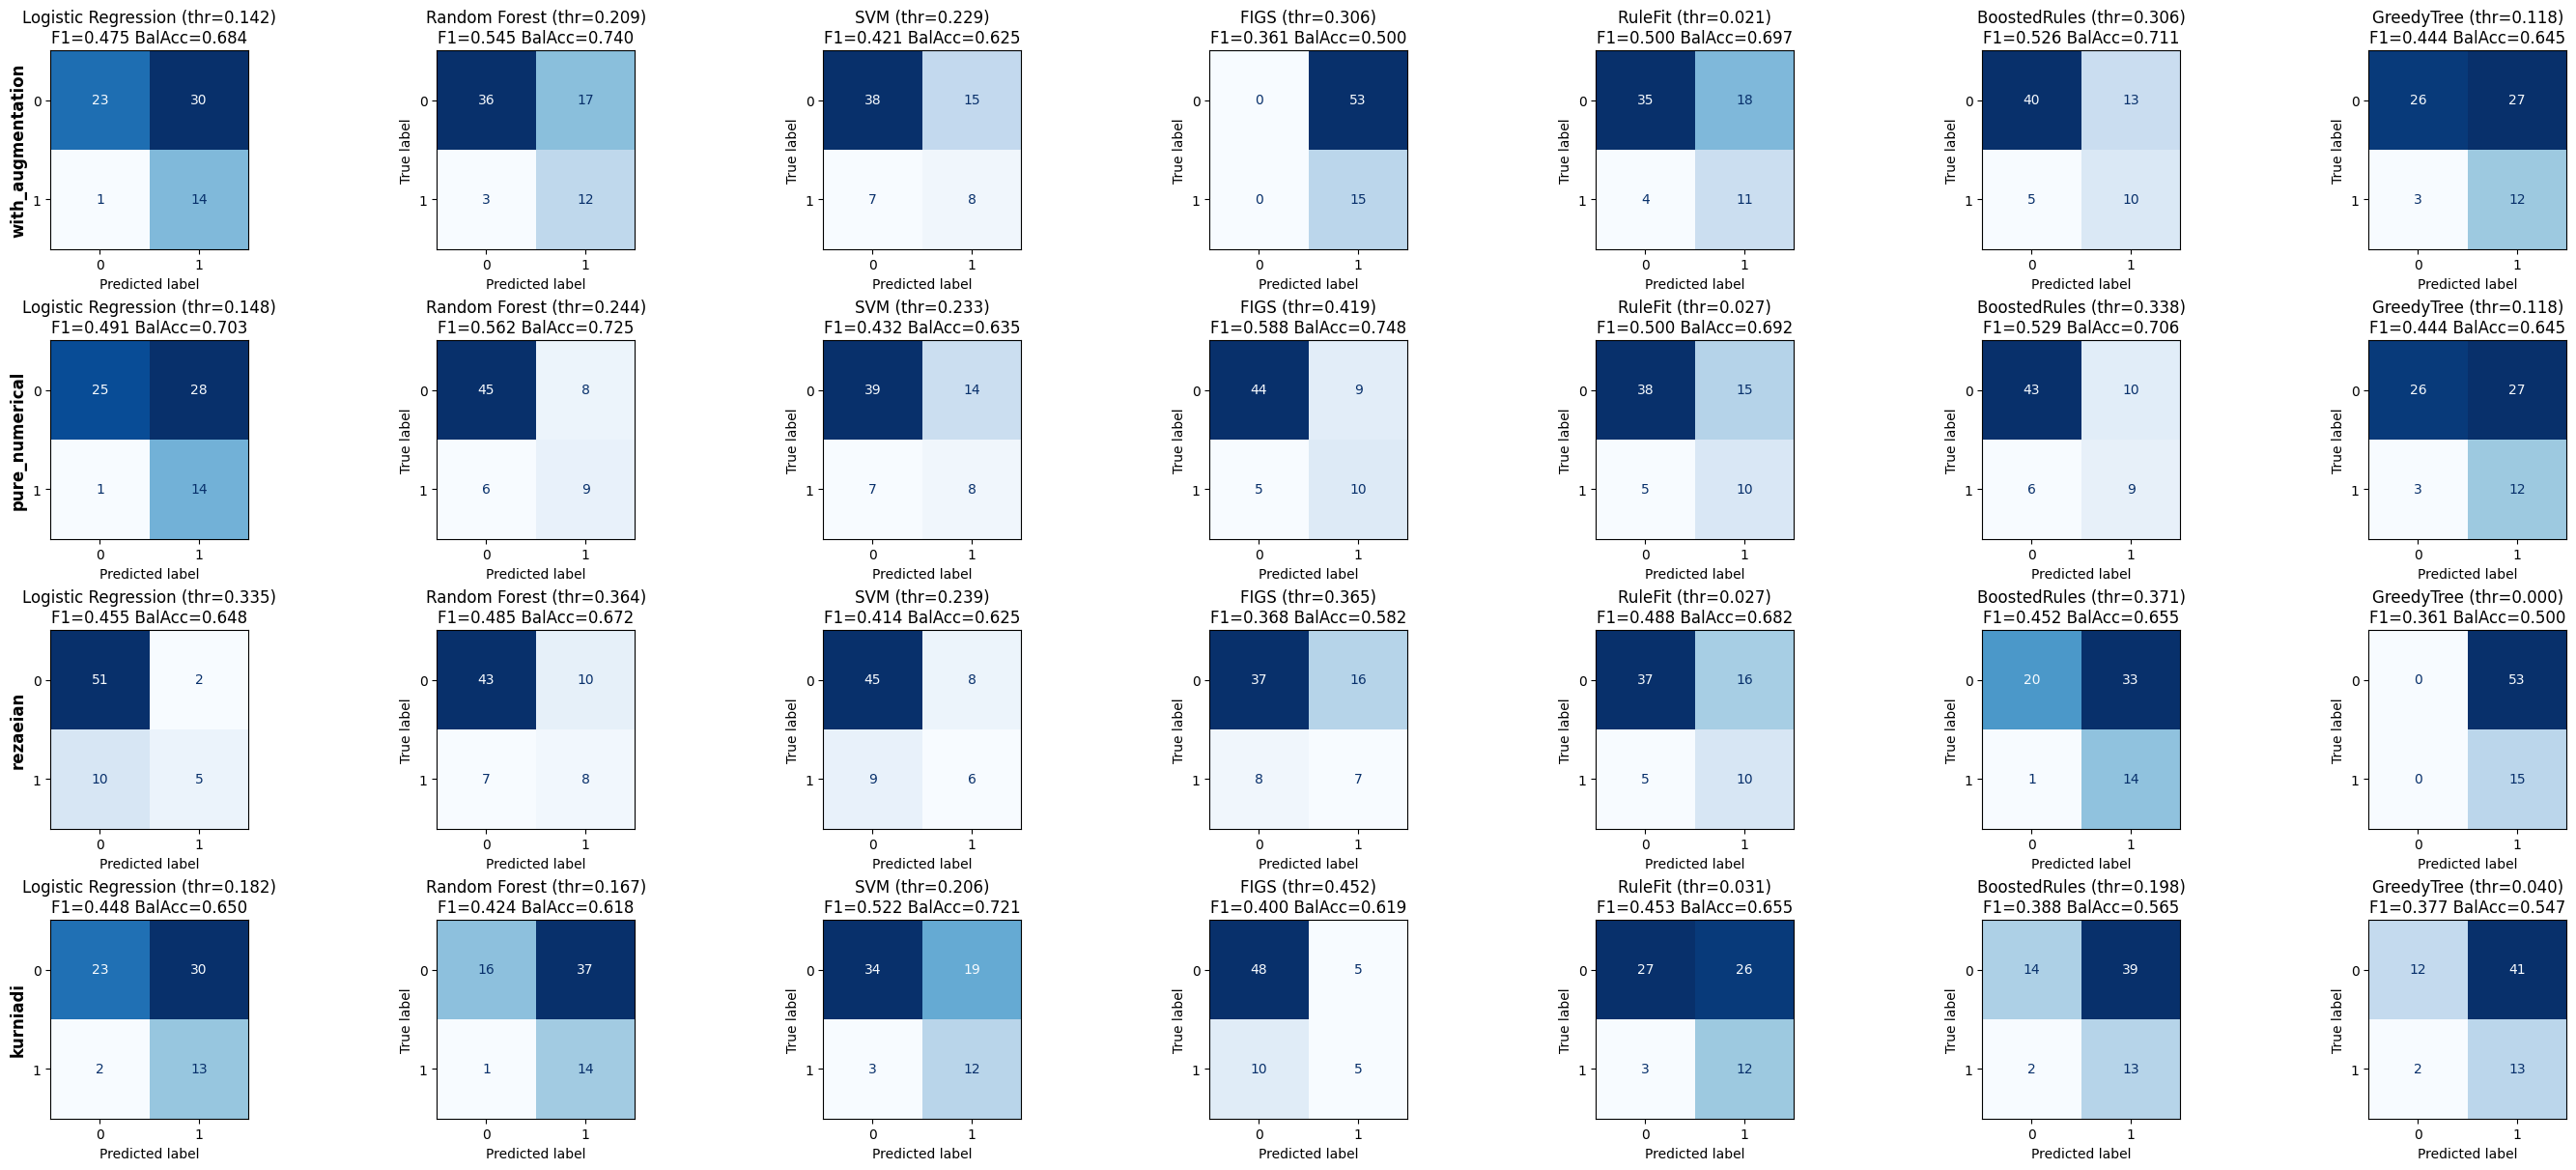

In [11]:
# --- Attach tuned_rows info into results ---
# (assumes same ordering)
for r, row in zip(results, tuned_rows):
    r["pr_threshold"] = row["pr_threshold"]
    r["pr_f1"] = row["pr_f1"]
    r["pr_bal_acc"] = row["pr_bal_acc"]


# --- Group by feature_space ---
grouped = defaultdict(list)
for r in results:
    grouped[r["feature_space"]].append(r)


# --- Grid size ---
n_rows = len(grouped)
n_cols = max(len(models) for models in grouped.values())

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(4 * n_cols, 3 * n_rows)
)

axes = np.atleast_2d(axes)


# --- Plot ---
for row_idx, (fs, row_results) in enumerate(grouped.items()):
    for col_idx, r in enumerate(row_results):
        ax = axes[row_idx, col_idx]

        # ✅ PR-threshold predictions
        preds = (r["proba"] >= r["pr_threshold"]).astype(int)

        title = (
            f"{r['model']} "
            f"(thr={r['pr_threshold']:.3f})\n"
            f"F1={r['pr_f1']:.3f} BalAcc={r['pr_bal_acc']:.3f}"
        )

        plot_confusion_matrix(
            r["y_test"],
            preds,
            title=title,
            ax=ax
        )

        # Y-axis label per feature space
        if col_idx == 0:
            ax.set_ylabel(fs, fontsize=12, fontweight="bold")

    # Hide empty cells
    for col_idx in range(len(row_results), n_cols):
        axes[row_idx, col_idx].axis("off")


# --- Layout ---
fig.set_constrained_layout(True)
plt.show()

In [12]:
# # Confusion matrices with the PR-tuned threshold
# for r, row in zip(results, tuned_rows):
#     preds = (r['proba'] >= row['pr_threshold']).astype(int)
#     title = (
#         f"{r['feature_space']} / {r['model']}  "
#         f"(PR thr={row['pr_threshold']:.3f}, F1={row['pr_f1']:.3f} BalAcc={row['pr_bal_acc']:.3f})"
#     )
#     plot_confusion_matrix(r['y_test'], preds, title=title)

## 8. Summary: Best Model per Feature-Space Approach

In [13]:
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('proba', 'grid', 'y_test', 'X_test')}
    for r in results
])

# Round numeric columns to 3 decimals
numeric_cols = df_results.select_dtypes(include='number').columns
df_results[numeric_cols] = df_results[numeric_cols].round(3)

# Best model per feature-space approach (by test AUC)
best_per_approach = df_results.loc[
    df_results.groupby('model_family')['test_auc'].idxmax(),
    ['feature_space', 'model_family', 'model', 'test_auc', 'test_ap', 'test_f1', 'test_bal_acc', 'best_params']
]

display(best_per_approach)

print("Best model per feature-space approach (by Test AUC):")

,feature_space,model_family,model,test_auc,test_ap,test_f1,test_bal_acc,best_params
5,with_augmentation,Interpretable,BoostedRules,0.752,0.538,0.125,0.533,"{'classifier__estimator__max_depth': 1, 'class..."
8,pure_numerical,Standard ML,Random Forest,0.757,0.480,0.000,0.500,"{'classifier__class_weight': None, 'classifier..."


Best model per feature-space approach (by Test AUC):


## 9. Full Leaderboard

In [ ]:
df_results.sort_values('test_auc', ascending=False)[
    ['feature_space', 'model_family', 'model',
     'cv_auc', 'cv_ap', 'cv_f1', 'cv_bal_acc',
     'test_auc', 'test_ap', 'test_f1', 'test_bal_acc']]

,feature_space,model_family,model,cv_auc,cv_ap,cv_f1,cv_bal_acc,test_auc,test_ap,test_f1,test_bal_acc
8,pure_numerical,Standard ML,Random Forest,0.680,0.365,0.000,0.500,0.757,0.480,0.000,0.500
5,with_augmentation,Interpretable,BoostedRules,0.663,0.363,0.133,0.527,0.752,0.538,0.125,0.533
12,pure_numerical,Interpretable,BoostedRules,0.670,0.359,0.109,0.528,0.743,0.464,0.000,0.500
10,pure_numerical,Interpretable,FIGS,0.651,0.337,0.293,0.564,0.742,0.516,0.308,0.567
23,kurniadi,Standard ML,SVM,0.585,0.281,0.372,0.581,0.735,0.516,0.455,0.654
1,with_augmentation,Standard ML,Random Forest,0.661,0.344,0.000,0.500,0.731,0.435,0.000,0.500
4,with_augmentation,Interpretable,RuleFit,0.724,0.446,0.000,0.500,0.724,0.464,0.000,0.500
11,pure_numerical,Interpretable,RuleFit,0.706,0.386,0.042,0.508,0.692,0.422,0.000,0.500
7,pure_numerical,Standard ML,Logistic Regression,0.662,0.363,0.140,0.529,0.668,0.449,0.125,0.533
15,rezaeian,Standard ML,Random Forest,0.589,0.336,0.085,0.521,0.664,0.421,0.111,0.514


## 10. Export Best Config per Experiment

In [20]:
df_tuned

,feature_space,model_family,model,default_f1,pr_threshold,pr_f1,pr_bal_acc,youden_threshold,youden_f1,youden_bal_acc
0,with_augmentation,Standard ML,Logistic Regression,0.125,0.142,0.475,0.684,0.142,0.475,0.684
1,with_augmentation,Standard ML,Random Forest,0.000,0.209,0.545,0.740,0.209,0.545,0.740
2,with_augmentation,Standard ML,SVM,0.000,0.229,0.421,0.625,0.229,0.421,0.625
3,with_augmentation,Interpretable,FIGS,0.087,0.306,0.361,0.500,0.383,0.286,0.548
4,with_augmentation,Interpretable,RuleFit,0.000,0.021,0.500,0.697,0.021,0.500,0.697
5,with_augmentation,Interpretable,BoostedRules,0.125,0.306,0.526,0.711,0.290,0.511,0.711
6,with_augmentation,Interpretable,GreedyTree,0.095,0.118,0.444,0.645,0.118,0.444,0.645
7,pure_numerical,Standard ML,Logistic Regression,0.125,0.148,0.491,0.703,0.148,0.491,0.703
8,pure_numerical,Standard ML,Random Forest,0.000,0.244,0.562,0.725,0.198,0.528,0.740
9,pure_numerical,Standard ML,SVM,0.000,0.233,0.432,0.635,0.233,0.432,0.635


In [26]:
# Best config per experiment = best model within each (feature_space, model_family) combo
best_per_experiment = df_results.loc[
    df_results.groupby(['feature_space', 'model_family'])['test_auc'].idxmax()
].sort_values('test_auc', ascending=False)


# Check for overlapping columns
overlap_cols = set(best_per_experiment.columns) & set(df_tuned.columns) - {'feature_space', 'model_family', 'model'}
print(f"Duplicate columns causing suffixes: {overlap_cols}")


# Merge PR-tuned threshold and metrics from df_tuned
best_export = best_per_experiment.merge(
    df_tuned[['feature_space', 'model_family', 'model']],
    on=['feature_space', 'model_family', 'model'],
    how='left',
)

# Use default threshold (0.5) when PR threshold is missing/NaN
best_export['threshold'] = best_export['pr_threshold'].fillna(0.5)
best_export['tuned_f1'] = best_export['pr_f1'].fillna(best_export['test_f1'])
best_export['tuned_bal_acc'] = best_export['pr_bal_acc'].fillna(best_export['test_bal_acc'])
best_export = best_export.drop(columns=['pr_threshold', 'pr_f1', 'pr_bal_acc'])
best_export.sort_values(['feature_space', 'model_family'],inplace=True)

display(best_export[[
    'feature_space', 'model_family', 'model',
    'threshold', 'tuned_f1', 'tuned_bal_acc',
    'cv_auc', 'cv_ap', 'cv_f1', 'cv_bal_acc',
    'test_auc', 'test_ap', 'test_f1', 'test_bal_acc',
    'best_params',
]].round(3))

# Export to CSV
best_export.to_csv('../results/best_config_per_experiment.csv', index=False)
print("Exported to (Project root)/results/best_config_per_experiment.csv")

Duplicate columns causing suffixes: {'pr_f1', 'pr_threshold', 'pr_bal_acc'}


,feature_space,model_family,model,threshold,tuned_f1,tuned_bal_acc,cv_auc,cv_ap,cv_f1,cv_bal_acc,test_auc,test_ap,test_f1,test_bal_acc,best_params
7,kurniadi,Interpretable,RuleFit,0.031,0.453,0.655,0.609,0.318,0.000,0.500,0.649,0.368,0.000,0.500,"{'classifier__max_rules': 15, 'classifier__n_e..."
3,kurniadi,Standard ML,SVM,0.206,0.522,0.721,0.585,0.281,0.372,0.581,0.735,0.516,0.455,0.654,"{'classifier__C': 0.1, 'classifier__class_weig..."
2,pure_numerical,Interpretable,BoostedRules,0.338,0.529,0.706,0.670,0.359,0.109,0.528,0.743,0.464,0.000,0.500,"{'classifier__estimator__max_depth': 1, 'class..."
0,pure_numerical,Standard ML,Random Forest,0.244,0.562,0.725,0.680,0.365,0.000,0.500,0.757,0.480,0.000,0.500,"{'classifier__class_weight': None, 'classifier..."
6,rezaeian,Interpretable,RuleFit,0.027,0.488,0.682,0.584,0.279,0.000,0.500,0.651,0.481,0.000,0.500,"{'classifier__max_rules': 15, 'classifier__n_e..."
5,rezaeian,Standard ML,Random Forest,0.364,0.485,0.672,0.589,0.336,0.085,0.521,0.664,0.421,0.111,0.514,"{'classifier__class_weight': 'balanced', 'clas..."
1,with_augmentation,Interpretable,BoostedRules,0.306,0.526,0.711,0.663,0.363,0.133,0.527,0.752,0.538,0.125,0.533,"{'classifier__estimator__max_depth': 1, 'class..."
4,with_augmentation,Standard ML,Random Forest,0.209,0.545,0.740,0.661,0.344,0.000,0.500,0.731,0.435,0.000,0.500,"{'classifier__class_weight': None, 'classifier..."


Exported to (Project root)/results/best_config_per_experiment.csv


## 11. Full Tuned-Threshold Results (All Models)

In [28]:
df_all_tuned

,feature_space,model_family,model,best_params,cv_auc,cv_ap,cv_f1,cv_bal_acc,test_auc,test_ap,...,test_bal_acc,pr_threshold_x,pr_f1_x,pr_bal_acc_x,pr_threshold_y,pr_f1_y,pr_bal_acc_y,youden_threshold,youden_f1,youden_bal_acc
0,with_augmentation,Standard ML,Logistic Regression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.667,0.364,0.161,0.536,0.658,0.426,...,0.533,0.142,0.475,0.684,0.142,0.475,0.684,0.142,0.475,0.684
1,with_augmentation,Standard ML,Random Forest,"{'classifier__class_weight': None, 'classifier...",0.661,0.344,0.000,0.500,0.731,0.435,...,0.500,0.209,0.545,0.740,0.209,0.545,0.740,0.209,0.545,0.740
2,with_augmentation,Standard ML,SVM,"{'classifier__C': 0.1, 'classifier__class_weig...",0.677,0.376,0.000,0.500,0.623,0.415,...,0.500,0.229,0.421,0.625,0.229,0.421,0.625,0.229,0.421,0.625
3,with_augmentation,Interpretable,FIGS,"{'classifier__max_depth': 2, 'classifier__max_...",0.646,0.338,0.265,0.559,0.482,0.234,...,0.467,0.306,0.361,0.500,0.306,0.361,0.500,0.383,0.286,0.548
4,with_augmentation,Interpretable,RuleFit,"{'classifier__max_rules': 15, 'classifier__n_e...",0.724,0.446,0.000,0.500,0.724,0.464,...,0.500,0.021,0.500,0.697,0.021,0.500,0.697,0.021,0.500,0.697
5,with_augmentation,Interpretable,BoostedRules,"{'classifier__estimator__max_depth': 1, 'class...",0.663,0.363,0.133,0.527,0.752,0.538,...,0.533,0.306,0.526,0.711,0.306,0.526,0.711,0.290,0.511,0.711
6,with_augmentation,Interpretable,GreedyTree,"{'classifier__class_weight': None, 'classifier...",0.622,0.282,0.127,0.512,0.640,0.333,...,0.486,0.118,0.444,0.645,0.118,0.444,0.645,0.118,0.444,0.645
7,pure_numerical,Standard ML,Logistic Regression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.662,0.363,0.140,0.529,0.668,0.449,...,0.533,0.148,0.491,0.703,0.148,0.491,0.703,0.148,0.491,0.703
8,pure_numerical,Standard ML,Random Forest,"{'classifier__class_weight': None, 'classifier...",0.680,0.365,0.000,0.500,0.757,0.480,...,0.500,0.244,0.562,0.725,0.244,0.562,0.725,0.198,0.528,0.740
9,pure_numerical,Standard ML,SVM,"{'classifier__C': 0.1, 'classifier__class_weig...",0.671,0.372,0.000,0.500,0.614,0.405,...,0.500,0.233,0.432,0.635,0.233,0.432,0.635,0.233,0.432,0.635


In [ ]:
# Merge tuned thresholds into the full results table
df_all_tuned = df_results.merge(
    df_tuned[['feature_space', 'model_family', 'model',
              'youden_threshold', 'youden_f1', 'youden_bal_acc']],
    on=['feature_space', 'model_family', 'model'],
    how='left',
)

df_all_tuned.sort_values('test_auc', ascending=False)[[
    'feature_space', 'model_family', 'model',
    'test_auc', 'test_ap', 'test_f1', 'test_bal_acc',
    'pr_threshold', 'pr_f1', 'pr_bal_acc',
    'youden_threshold', 'youden_f1', 'youden_bal_acc',
]].round(3)

,feature_space,model_family,model,test_auc,test_ap,test_f1,test_bal_acc,pr_threshold,pr_f1,pr_bal_acc,youden_threshold,youden_f1,youden_bal_acc
8,pure_numerical,Standard ML,Random Forest,0.757,0.480,0.000,0.500,0.244,0.562,0.725,0.198,0.528,0.740
5,with_augmentation,Interpretable,BoostedRules,0.752,0.538,0.125,0.533,0.306,0.526,0.711,0.290,0.511,0.711
12,pure_numerical,Interpretable,BoostedRules,0.743,0.464,0.000,0.500,0.338,0.529,0.706,0.305,0.512,0.706
10,pure_numerical,Interpretable,FIGS,0.742,0.516,0.308,0.567,0.419,0.588,0.748,0.419,0.588,0.748
23,kurniadi,Standard ML,SVM,0.735,0.516,0.455,0.654,0.206,0.522,0.721,0.198,0.520,0.726
1,with_augmentation,Standard ML,Random Forest,0.731,0.435,0.000,0.500,0.209,0.545,0.740,0.209,0.545,0.740
4,with_augmentation,Interpretable,RuleFit,0.724,0.464,0.000,0.500,0.021,0.500,0.697,0.021,0.500,0.697
11,pure_numerical,Interpretable,RuleFit,0.692,0.422,0.000,0.500,0.027,0.500,0.692,0.027,0.500,0.692
7,pure_numerical,Standard ML,Logistic Regression,0.668,0.449,0.125,0.533,0.148,0.491,0.703,0.148,0.491,0.703
15,rezaeian,Standard ML,Random Forest,0.664,0.421,0.111,0.514,0.364,0.485,0.672,0.364,0.485,0.672


In [30]:
df_all_tuned.shape

(28, 18)

## 12. Refit & Score Best Model per Experiment

Extract the winning model config from each experiment, refit on the full training set, and produce detailed test-set scoring at both the default (0.5) and PR-tuned thresholds.

In [31]:
# Build a lookup from (feature_space, model_family, model) -> results entry
results_lookup = {
    (r['feature_space'], r['model_family'], r['model']): r
    for r in results
}

best_model_reports = []

for _, row in best_per_experiment.iterrows():
    key = (row['feature_space'], row['model_family'], row['model'])
    r = results_lookup[key]

    # The grid already contains the best estimator fitted on X_train
    best_pipeline = r['grid'].best_estimator_
    X_test_exp = r['X_test']
    y_test_exp = r['y_test']

    # Predict probabilities and default predictions
    proba = best_pipeline.predict_proba(X_test_exp)[:, 1]
    y_pred_default = best_pipeline.predict(X_test_exp)

    # PR-tuned threshold
    thr_pr = find_best_threshold_pr(y_test_exp, proba)
    y_pred_tuned = (proba >= thr_pr).astype(int)

    # Scores at default threshold (0.5)
    default_scores = {
        'auc': roc_auc_score(y_test_exp, proba),
        'ap': average_precision_score(y_test_exp, proba),
        'f1': f1_score(y_test_exp, y_pred_default),
        'bal_acc': balanced_accuracy_score(y_test_exp, y_pred_default),
    }

    # Scores at PR-tuned threshold
    tuned_scores = {
        'auc': default_scores['auc'],  # AUC is threshold-independent
        'ap': default_scores['ap'],    # AP is threshold-independent
        'f1': f1_score(y_test_exp, y_pred_tuned),
        'bal_acc': balanced_accuracy_score(y_test_exp, y_pred_tuned),
    }

    best_model_reports.append({
        'feature_space': row['feature_space'],
        'model_family': row['model_family'],
        'model': row['model'],
        'best_params': row['best_params'],
        'default_f1': default_scores['f1'],
        'default_bal_acc': default_scores['bal_acc'],
        'pr_threshold': thr_pr,
        'tuned_f1': tuned_scores['f1'],
        'tuned_bal_acc': tuned_scores['bal_acc'],
        'test_auc': default_scores['auc'],
        'test_ap': default_scores['ap'],
    })

    # Print classification report per best model
    print(f"\n{'='*70}")
    print(f"  {row['feature_space']} / {row['model_family']} / {row['model']}")
    print(f"  PR-tuned threshold: {thr_pr:.3f}")
    print(f"{'='*70}")
    print("\n--- Default threshold (0.5) ---")
    print(classification_report(y_test_exp, y_pred_default, digits=3))
    print(f"--- PR-tuned threshold ({thr_pr:.3f}) ---")
    print(classification_report(y_test_exp, y_pred_tuned, digits=3))

df_best_models = pd.DataFrame(best_model_reports).round(3)
df_best_models


  pure_numerical / Standard ML / Random Forest
  PR-tuned threshold: 0.244

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

           0      0.779     1.000     0.876        53
           1      0.000     0.000     0.000        15

    accuracy                          0.779        68
   macro avg      0.390     0.500     0.438        68
weighted avg      0.607     0.779     0.683        68

--- PR-tuned threshold (0.244) ---
              precision    recall  f1-score   support

           0      0.882     0.849     0.865        53
           1      0.529     0.600     0.562        15

    accuracy                          0.794        68
   macro avg      0.706     0.725     0.714        68
weighted avg      0.804     0.794     0.799        68


  with_augmentation / Interpretable / BoostedRules
  PR-tuned threshold: 0.306

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

           0      0.791     1.000 

,feature_space,model_family,model,best_params,default_f1,default_bal_acc,pr_threshold,tuned_f1,tuned_bal_acc,test_auc,test_ap
0,pure_numerical,Standard ML,Random Forest,"{'classifier__class_weight': None, 'classifier...",0.000,0.500,0.244,0.562,0.725,0.757,0.480
1,with_augmentation,Interpretable,BoostedRules,"{'classifier__estimator__max_depth': 1, 'class...",0.125,0.533,0.306,0.526,0.711,0.752,0.538
2,pure_numerical,Interpretable,BoostedRules,"{'classifier__estimator__max_depth': 1, 'class...",0.000,0.500,0.338,0.529,0.706,0.743,0.464
3,kurniadi,Standard ML,SVM,"{'classifier__C': 0.1, 'classifier__class_weig...",0.455,0.654,0.206,0.522,0.721,0.735,0.516
4,with_augmentation,Standard ML,Random Forest,"{'classifier__class_weight': None, 'classifier...",0.000,0.500,0.209,0.545,0.740,0.731,0.435
5,rezaeian,Standard ML,Random Forest,"{'classifier__class_weight': 'balanced', 'clas...",0.111,0.514,0.364,0.485,0.672,0.664,0.421
6,rezaeian,Interpretable,RuleFit,"{'classifier__max_rules': 15, 'classifier__n_e...",0.000,0.500,0.027,0.488,0.682,0.651,0.481
7,kurniadi,Interpretable,RuleFit,"{'classifier__max_rules': 15, 'classifier__n_e...",0.000,0.500,0.031,0.453,0.655,0.649,0.368


In [33]:
df_best_models.loc[3]['best_params']

{'classifier__C': 0.1,
 'classifier__class_weight': 'balanced',
 'classifier__kernel': 'rbf'}

## Explainability

In [34]:
import shap

In [47]:
for _, row in best_per_experiment.iterrows():
    key = (row['feature_space'], row['model_family'], row['model'])
    r = results_lookup[key]
    print("Examined combination:", key)

Examined combination: ('pure_numerical', 'Standard ML', 'Random Forest')
Examined combination: ('with_augmentation', 'Interpretable', 'BoostedRules')
Examined combination: ('pure_numerical', 'Interpretable', 'BoostedRules')
Examined combination: ('kurniadi', 'Standard ML', 'SVM')
Examined combination: ('with_augmentation', 'Standard ML', 'Random Forest')
Examined combination: ('rezaeian', 'Standard ML', 'Random Forest')
Examined combination: ('rezaeian', 'Interpretable', 'RuleFit')
Examined combination: ('kurniadi', 'Interpretable', 'RuleFit')


Explored combination:  ('pure_numerical', 'Standard ML', 'Random Forest')


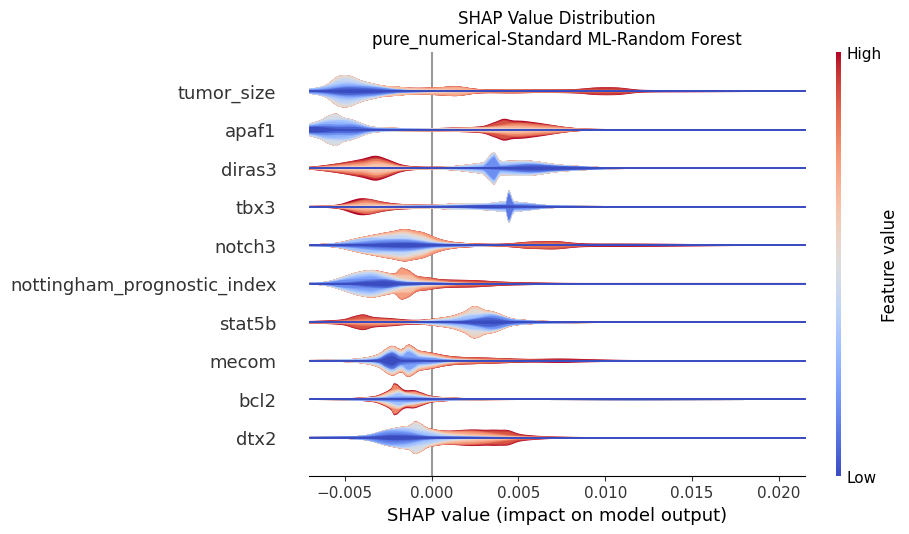

Explored combination:  ('kurniadi', 'Standard ML', 'SVM')


  0%|          | 0/68 [00:00<?, ?it/s]

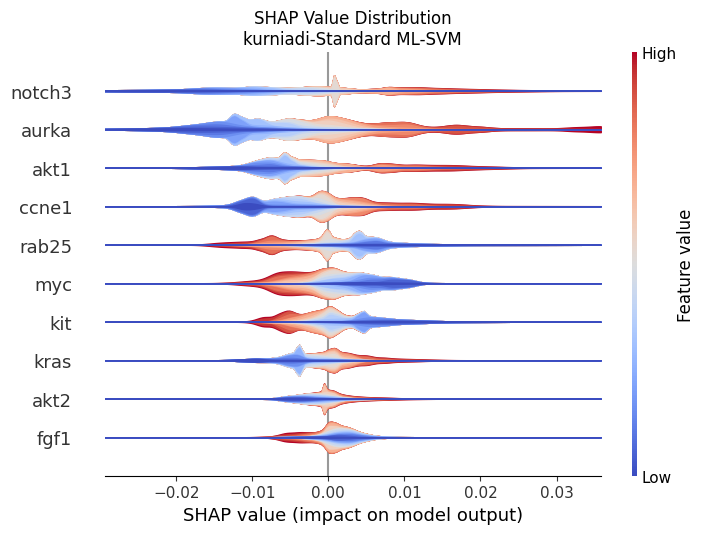

Explored combination:  ('with_augmentation', 'Standard ML', 'Random Forest')


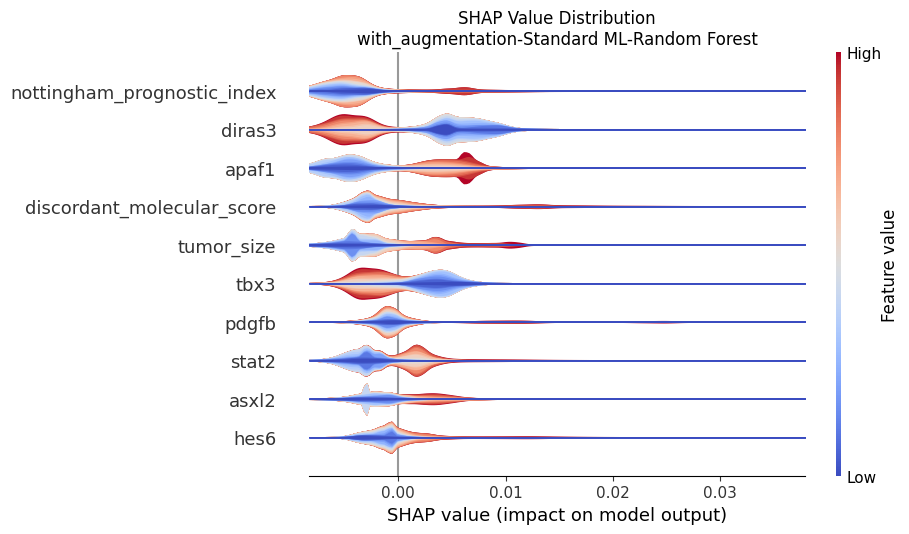

Explored combination:  ('rezaeian', 'Standard ML', 'Random Forest')


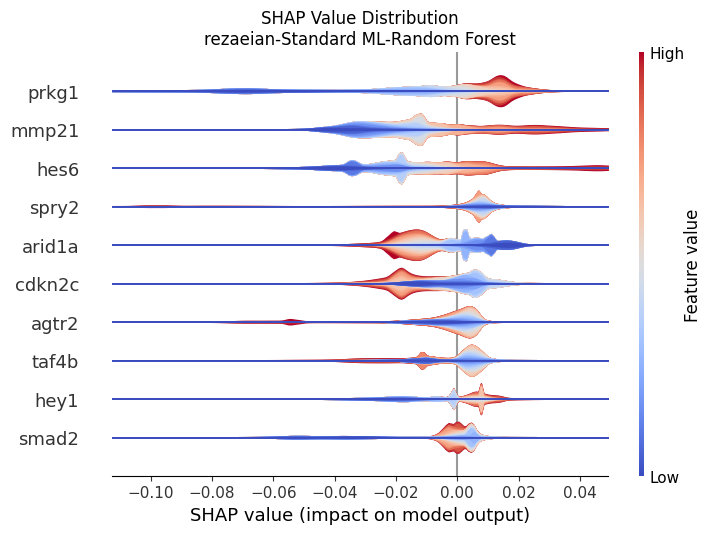

In [50]:
for _, row in best_per_experiment.iterrows():
    key = (row['feature_space'], row['model_family'], row['model'])
    r = results_lookup[key]
    #print("Examined combination:", key)

    if  key[2] == 'Random Forest':
        best_pipeline = r['grid'].best_estimator_
        print("Explored combination: ", key)

        X_test_exp = r['X_test']
        y_test_exp = r['y_test']

        # Isolate model
        model = best_pipeline.named_steps["classifier"]

        # All preprocessing steps together
        preprocess = best_pipeline[:-1]

        X_test_transformed = preprocess.transform(X_test_exp)

        # TreeExplainer calculates the exact marginal contribution of every clinical feature.
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_transformed)

        shap_values_death = shap_values[:,:,1]

        feature_names = preprocess.get_feature_names_out()
        shap.plots.violin(shap_values_death, features=X_test_transformed,
                        feature_names=feature_names, plot_type="layered_violin", 
                        max_display=10, show=False)
        
        plt.title(f"SHAP Value Distribution\n{key[0]}-{key[1]}-{key[2]}")
        plt.show()

    elif  key[2] == 'SVM':
        best_pipeline = r['grid'].best_estimator_
        print("Explored combination: ", key)

        X_test_exp = r['X_test']
        y_test_exp = r['y_test']

        # Isolate model
        model = best_pipeline.named_steps["classifier"]

        # All preprocessing steps together
        preprocess = best_pipeline[:-1]

        X_test_transformed = preprocess.transform(X_test_exp)

        # KernelExplainer estimates SHAP values via sampling, so it's more computationally expensive and less exact than TreeExplainer.
        explainer = shap.KernelExplainer(model.predict_proba, X_test_transformed)
        shap_values = explainer.shap_values(X_test_transformed)

        shap_values_death = shap_values[:,:,1]

        feature_names = preprocess.get_feature_names_out()
        shap.plots.violin(shap_values_death, features=X_test_transformed,
                        feature_names=feature_names, plot_type="layered_violin", 
                        max_display=10, show=False)
        
        plt.title(f"SHAP Value Distribution\n{key[0]}-{key[1]}-{key[2]}")
        plt.show()


In [51]:
#print(best_pipeline.named_steps)

In [52]:
# shap.summary_plot(shap_values_death,
#                     X_transformed,
#                     feature_names=feature_names, 
#                     max_display=10,
#                     show=False)


# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

In [57]:
for _, row in best_per_experiment.iterrows():
    key = (row['feature_space'], row['model_family'], row['model'])
    r = results_lookup[key]
    #print("Examined combination:", key)

    if  key[2] == 'RuleFit':
        best_pipeline = r['grid'].best_estimator_
        print("Explored combination: ", key)

        X_test_exp = r['X_test']
        y_test_exp = r['y_test']

        # Isolate model
        model = best_pipeline.named_steps["classifier"]


        rules = model.rules_without_feature_names_
        coefs = model.coef

        n_rules = len(rules)
        rule_coefs = coefs[:n_rules]

        rules_df = pd.DataFrame({
            'rule': rules,
            'coef': rule_coefs
        })
        rules_df = rules_df[rules_df['coef'] != 0]
        rules_df = rules_df.reindex(rules_df['coef'].abs().sort_values(ascending=False).index)

        print(f"Total non-zero rules: {len(rules_df)}")
        print(f"\nTop 10 rules by coefficient magnitude:")
        for _, row in rules_df.head(10).iterrows():
            print(f"  coef={row['coef']:+.4f} | {row['rule']}")

Explored combination:  ('rezaeian', 'Interpretable', 'RuleFit')
Total non-zero rules: 0

Top 10 rules by coefficient magnitude:
Explored combination:  ('kurniadi', 'Interpretable', 'RuleFit')
Total non-zero rules: 0

Top 10 rules by coefficient magnitude:


In [60]:
rule_coefs

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

In [56]:
dir(model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_eval_weighted_rule_sum',
 '_extract_rules',
 '_get_class_level_metadata_request_values',
 '_get_complexity',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_get_rules',
 '_html_repr',
 '_predict_continuous_output',
 '_prune_rules',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_score_rules',
 '_sklearn_auto_wrap_output_keys',
 '_validate_params',
 'alpha',
 'classes_',
 'coef',
 'complexity_',
 